In [5]:
# ============================================================
# Customer Segmentation using Hierarchical Clustering
# Part 1 : Data Loading and Agglomerative Clustering
# ============================================================

# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

# ==========================
# Load Dataset
# ==========================

df=pd.read_csv('../data/Mall_Customers.csv')

# ==========================
# Display Dataset
# ==========================

display(df.head())

print("\nDataset Shape")

print(df.shape)

print("\nColumns")

print(df.columns)

print("\nInformation")

print(df.info())

print("\nMissing Values")

print(df.isnull().sum())



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Shape
(200, 5)

Columns
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
# ==========================
# Remove Duplicate Rows
# ==========================

duplicates = df.duplicated().sum()

print("\nDuplicate Rows")

print(duplicates)

df.drop_duplicates(inplace=True)

# ==========================
# Encode Gender
# ==========================

encoder = LabelEncoder()

df["Genre"] = encoder.fit_transform(

    df["Genre"]

)

# ==========================
# Feature Selection
# ==========================

X = df[[

    "Age",

    "Annual Income (k$)",

    "Spending Score (1-100)"

]]

# ==========================
# Feature Scaling
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(

    X

)

# ==========================
# Save Scaler
# ==========================

joblib.dump(

    scaler,

    "hierarchical_scaler.pkl"

)

print("\nScaler Saved Successfully")





Duplicate Rows
0

Scaler Saved Successfully


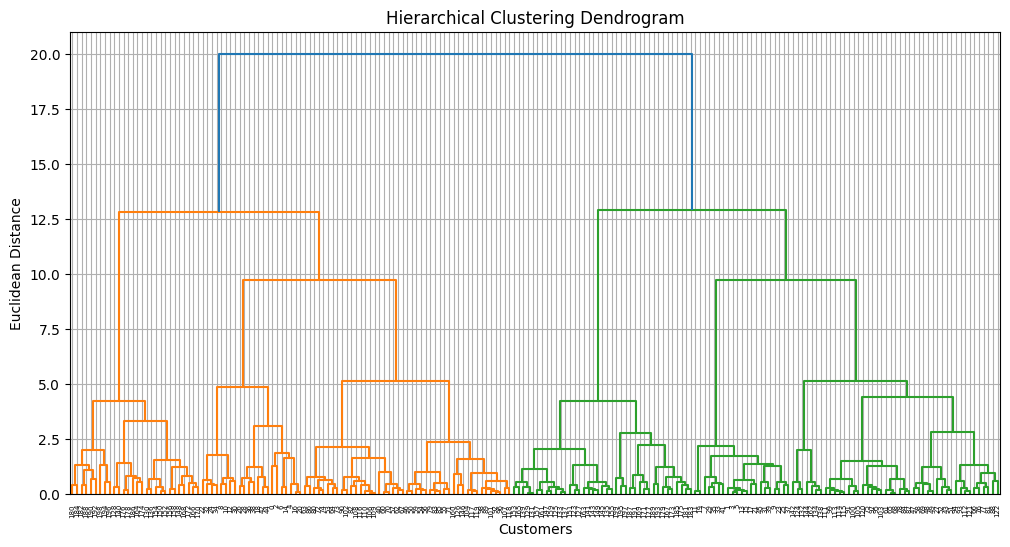

In [7]:
# ==========================
# Create Dendrogram
# ==========================

plt.figure(figsize=(12,6))

linkage_matrix = linkage(

    X_scaled,

    method="ward"

)

dendrogram(

    linkage_matrix

)

plt.title(

    "Hierarchical Clustering Dendrogram"

)

plt.xlabel(

    "Customers"

)

plt.ylabel(

    "Euclidean Distance"

)

plt.grid(True)

plt.show()


In [8]:
# ==========================
# Train Hierarchical Model
# ==========================

model = AgglomerativeClustering(

    n_clusters=5,

    metric="euclidean",

    linkage="ward"

)

clusters = model.fit_predict(

    X_scaled

)

# ==========================
# Add Cluster Labels
# ==========================

df["Cluster"] = clusters

# ==========================
# Display Cluster Counts
# ==========================

print("\nCustomers in Each Cluster")

print(

    df["Cluster"].value_counts()

)



Customers in Each Cluster
Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64



Silhouette Score
0.39002826186267214

Davies-Bouldin Score
0.9162886109753661

Calinski-Harabasz Score
107.82656032570374


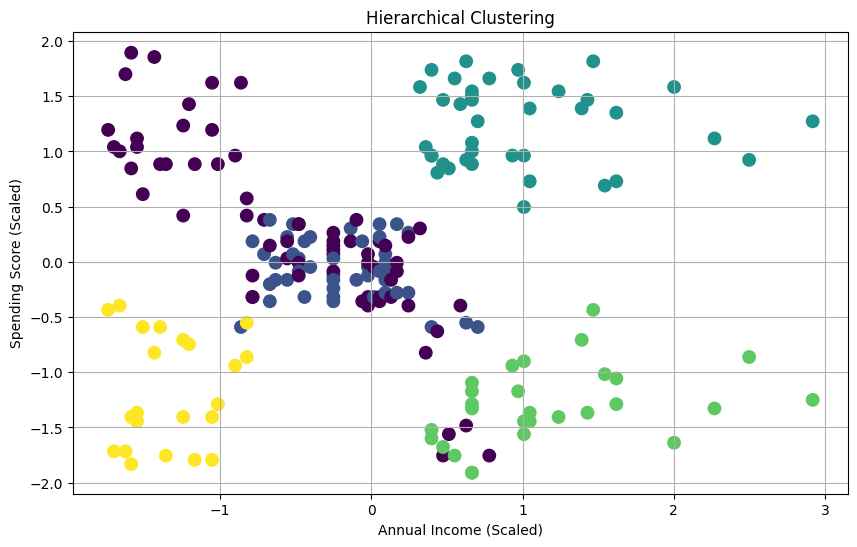


Customers in Each Cluster
Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64

Cluster Summary
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        26.560606           47.363636               56.787879
1        56.400000           55.288889               48.355556
2        32.692308           86.538462               82.128205
3        43.892857           91.285714               16.678571
4        44.318182           25.772727               20.272727

========== Cluster 0 ==========
   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
1           2      1   21                  15                      81        0
3           4      0   23                  16                      77        0
5           6      0   22                  17                      76        0
7           8      0   23                  18                      94        0
9          10

In [9]:
# ============================================================
# Customer Segmentation using Hierarchical Clustering
# Part 2 : Visualization and Evaluation
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (

    silhouette_score,

    davies_bouldin_score,

    calinski_harabasz_score

)

# ==========================
# Silhouette Score
# ==========================

silhouette = silhouette_score(

    X_scaled,

    clusters

)

print("\nSilhouette Score")

print(silhouette)

# ==========================
# Davies-Bouldin Score
# ==========================

davies = davies_bouldin_score(

    X_scaled,

    clusters

)

print("\nDavies-Bouldin Score")

print(davies)

# ==========================
# Calinski-Harabasz Score
# ==========================

calinski = calinski_harabasz_score(

    X_scaled,

    clusters

)

print("\nCalinski-Harabasz Score")

print(calinski)

# ==========================
# Scatter Plot
# ==========================

plt.figure(figsize=(10,6))

plt.scatter(

    X_scaled[:,1],

    X_scaled[:,2],

    c=clusters,

    cmap="viridis",

    s=80

)

plt.title(

    "Hierarchical Clustering"

)

plt.xlabel(

    "Annual Income (Scaled)"

)

plt.ylabel(

    "Spending Score (Scaled)"

)

plt.grid(True)

plt.show()

# ==========================
# Cluster Counts
# ==========================

print("\nCustomers in Each Cluster")

print(

    df["Cluster"].value_counts()

)

# ==========================
# Cluster Summary
# ==========================

summary = df.groupby(

    "Cluster"

)[

    [

        "Age",

        "Annual Income (k$)",

        "Spending Score (1-100)"

    ]

].mean()

print("\nCluster Summary")

print(summary)

# ==========================
# Display Customers
# ==========================

for cluster in sorted(

    df["Cluster"].unique()

):

    print(f"\n========== Cluster {cluster} ==========")

    print(

        df[

            df["Cluster"] == cluster

        ].head()

    )

print("\nPart 2 Completed Successfully")

In [10]:
# ============================================================
# Customer Segmentation using Hierarchical Clustering
# Part 3 : New Customer Analysis
# ============================================================

import pandas as pd
import numpy as np
import joblib

from scipy.spatial.distance import cdist

# ==========================
# Load Saved Scaler
# ==========================

loaded_scaler = joblib.load(

    "hierarchical_scaler.pkl"

)

print("\nScaler Loaded Successfully")

# ==========================
# New Customer
# ==========================

customer = [[

    30,     # Age

    60,     # Annual Income (k$)

    75      # Spending Score (1-100)

]]

# ==========================
# Scale New Customer
# ==========================

customer_scaled = loaded_scaler.transform(

    customer

)

# ==========================
# Find Mean of Each Cluster
# ==========================

cluster_means = []

for cluster in sorted(df["Cluster"].unique()):

    mean = X_scaled[df["Cluster"] == cluster].mean(axis=0)

    cluster_means.append(mean)

cluster_means = np.array(cluster_means)

# ==========================
# Calculate Distance
# ==========================

distances = cdist(

    customer_scaled,

    cluster_means,

    metric="euclidean"

)

# ==========================
# Nearest Cluster
# ==========================

predicted_cluster = np.argmin(

    distances

)

print("\nNearest Cluster")

print(predicted_cluster)

# ==========================
# Distance to Every Cluster
# ==========================

print("\nDistances")

for i, d in enumerate(distances[0]):

    print(

        f"Cluster {i}: {d:.4f}"

    )

# ==========================
# Show Similar Customers
# ==========================

print("\nSample Customers From Predicted Cluster")

print(

    df[

        df["Cluster"] == predicted_cluster

    ].head()

)

# ==========================
# Save Clustered Dataset
# ==========================

df.to_csv(

    "customer_clusters.csv",

    index=False

)

print("\nClustered Dataset Saved Successfully")

print("\nPart 3 Completed Successfully")


Scaler Loaded Successfully

Nearest Cluster
0

Distances
Cluster 0: 0.8908
Cluster 1: 2.1661
Cluster 2: 1.0677
Cluster 3: 2.7471
Cluster 4: 2.6975

Sample Customers From Predicted Cluster
   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
1           2      1   21                  15                      81        0
3           4      0   23                  16                      77        0
5           6      0   22                  17                      76        0
7           8      0   23                  18                      94        0
9          10      0   30                  19                      72        0

Clustered Dataset Saved Successfully

Part 3 Completed Successfully


c:\Users\Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
